Imports

In [1]:
# imports
from esdl import esdl
from esdl.esdl_handler import EnergySystemHandler
import pandas as pd
import numpy as np
import numpy_financial as npf
from decimal import Decimal, ROUND_HALF_UP
import matplotlib.pyplot as plt
import pickle

from func_calendar_businesscase_operations_decommissioning_years_lists import *

#########################

# Load the Pickle file with stored data from Operation_analysis
filename = 'Operation_Analysis_variables.pkl'
with open(filename, 'rb') as f:
    variables = pickle.load(f)

# Select the variables that are needed for this calculation
specific_vars = {key: variables[key] for key in ['efficiency_electrolyser_LHV', 'windfarm_capacity', 'solar_capacity'] if key in variables}

# Use the specific variables in the current environment
globals().update(specific_vars)

name                power efficiency investment_costs fixed_opex  \
TNVDW         700000000.0                      1750.0       2.25   
Electrolyzer        500.0        0.6           2000.0        2.0   
Offtaker       24900000.0                         0.0        0.0   

name         variable_opex  wacc  
TNVDW                  5.0   8.5  
Electrolyzer           0.0  8.25  
Offtaker               0.0  10.5  
All variables saved to NSE_get_data_from_ESDL.pkl


Choose parameters for analysis

In [2]:
#include a range of distances from OS to shore for the analysis
min_distance = 50
max_distance = 350  +1
steps_distance = 50

distances = np.arange(min_distance, max_distance, steps_distance)

print(distances)

efficiency_cables = 0.92
efficiency_pipes = 1.0
efficiency_electrolyser = efficiency_electrolyser_LHV
volume_start = 100 #means 100 procent of the volumes of the windfarm

volume_end_onshore_vc = volume_start*efficiency_cables*efficiency_electrolyser
volume_end_offshore_vc = volume_start*efficiency_electrolyser*efficiency_pipes

#please make sure to set the right capacity and volume values in the input data files of every business case type (especially HT)

[ 50 100 150 200 250 300 350]


Run Offshore Windfarm

In [3]:
from OWF_input_data import *
from ipynb.fs.defs.OWF_working_file import (levelized_cost_and_revenues)

df_OWF_levelized_costs = levelized_cost_and_revenues(owf_capex,
                                    df_owf_opex,
                                    owf_inflation,
                                    owf_revenues_to_electrolyser,
                                    owf_revenues_to_market,
                                    owf_loan_percentage,
                                    owf_loan_interest_rate,
                                    owf_income_tax_rate,
                                    owf_general_WACC,
                                    duration_operation)

#print(df_OWF_levelized_costs_on_on)
print(duration_operation)


df_OWF_levelized_costs = df_OWF_levelized_costs.drop(columns=["revenues"])
df_OWF_levelized_costs = df_OWF_levelized_costs.drop(labels=['tax_expenses', 'revenues_ppa', 'revenues_market', 'profits', 'unprofitable_gap'])
df_OWF_levelized_costs.index = ['OWF ' + str(index) for index in df_OWF_levelized_costs.index]

#Adjust levelized costs for the losses within the chain (e.g. if there are losses in the cables more wind energy is needed to provide the same volume of hydrogen at the end of the chain)
df_OWF_levelized_costs_on = df_OWF_levelized_costs * ((volume_start)/volume_end_onshore_vc)
df_OWF_levelized_costs_off = df_OWF_levelized_costs * ((volume_start)/volume_end_offshore_vc)

print(df_OWF_levelized_costs)


electricity sold =    Pessimistic  Most likely  Optimistic
0   61353600.0   61353600.0  61353600.0 MWh
hydrogen sold =     Pessimistic   Most likely    Optimistic
0  3.698755e+07  3.698755e+07  3.698755e+07 MWh
electricity sold =    Pessimistic  Most likely  Optimistic
0   61353600.0   61353600.0  61353600.0 MWh
hydrogen sold =     Pessimistic   Most likely    Optimistic
0  3.698755e+07  3.698755e+07  3.698755e+07 MWh
electricity sold =    Pessimistic  Most likely  Optimistic
0   61353600.0   61353600.0  61353600.0 MWh
hydrogen sold =     Pessimistic   Most likely    Optimistic
0  3.698755e+07  3.698755e+07  3.698755e+07 MWh
All variables saved to Operation_Analysis_variables.pkl
25
levelized cost calculations       cost
OWF capex                    50.128840
OWF opex                     10.365331
OWF decommissioning           0.352333
OWF interest_costs            9.876009
OWF contingency               5.378784


Offshore solar

In [4]:
from OS_input_data import *
from ipynb.fs.defs.OS_working_file import (levelized_cost_and_revenues)

df_OS_levelized_costs = levelized_cost_and_revenues(OS_capex,
                            df_OS_opex,
                            OS_inflation,
                            OS_revenues_to_electrolyser,
                            OS_revenues_to_market,
                            OS_decomissioning_percentage,
                            OS_loan_percentage,
                            OS_loan_interest_rate,
                            OS_income_tax_rate,
                            OS_general_WACC,
                            OS_lifetime)

#print(df_OWF_levelized_costs_on_on)
print(OS_lifetime)


df_OS_levelized_costs = df_OS_levelized_costs.drop(columns=["revenues"])
df_OS_levelized_costs = df_OS_levelized_costs.drop(labels=['tax_expenses', 'revenues_ppa', 'revenues_market', 'profits', 'unprofitable_gap'])
df_OS_levelized_costs.index = ['OS ' + str(index) for index in df_OWF_levelized_costs.index]

#Adjust levelized costs for the losses within the chain (e.g. if there are losses in the cables more wind energy is needed to provide the same volume of hydrogen at the end of the chain)
df_OS_levelized_costs_on = df_OS_levelized_costs * ((volume_start)/volume_end_onshore_vc)
df_OS_levelized_costs_off = df_OS_levelized_costs * ((volume_start)/volume_end_offshore_vc)

print(df_OS_levelized_costs)

25
levelized cost calculations        cost
OS OWF capex                 159.013333
OS OWF opex                   28.731308
OS OWF decommissioning         0.336933
OS OWF interest_costs         31.327617
OS OWF contingency            17.062001


Electricity transport

In [5]:
from ET_input_data import *
from ipynb.fs.defs.ET_working_file import (levelized_cost_and_revenues)

counter = 0
for distance in distances:
    if counter == 0:
        ET_tot_capex = platform_capex + substation_capex + cable_capex_km*distance
        df_ET_costs_by_distance = levelized_cost_and_revenues(ET_tot_capex,
                                                platform_capex, 
                                                substation_capex, 
                                                cable_capex_km,
                                                df_ET_opex,
                                                ET_inflation,
                                                df_ET_revenue_transport, 
                                                df_ET_revenues_connections,
                                                ET_decomissioning_percentage,
                                                ET_loan_percentage,
                                                ET_loan_interest_rate,
                                                ET_income_tax_rate,
                                                ET_general_WACC,
                                                ET_lifetime,
                                                distance)
        df_ET_costs_by_distance = df_ET_costs_by_distance.drop(columns=["revenues"])
        df_ET_costs_by_distance = df_ET_costs_by_distance.rename(columns={"cost": distance})
        counter = 1
    else:
        ET_tot_capex = platform_capex + substation_capex + cable_capex_km*distance
        df_levelized_costs = levelized_cost_and_revenues(ET_tot_capex,
                                                platform_capex, 
                                                substation_capex, 
                                                cable_capex_km,
                                                df_ET_opex,
                                                ET_inflation,
                                                df_ET_revenue_transport, 
                                                df_ET_revenues_connections,
                                                ET_decomissioning_percentage,
                                                ET_loan_percentage,
                                                ET_loan_interest_rate,
                                                ET_income_tax_rate,
                                                ET_general_WACC,
                                                ET_lifetime,
                                                distance)['cost']
        df_ET_costs_by_distance = pd.concat([df_ET_costs_by_distance, df_levelized_costs.rename(distance)], axis=1)


#print(df_ET_costs_by_distance)
print(duration_operation)

df_ET_costs_by_distance = df_ET_costs_by_distance.drop(labels=['tax_expenses', 'revenues_connection_tariffs', 'revenues_transport_tariffs', 'profits', 'unprofitable_gap'])
df_ET_costs_by_distance.index = ['ET ' + str(index) for index in df_ET_costs_by_distance.index]

print(df_ET_costs_by_distance)

#Adjust levelized costs for the losses within the chain (e.g. if there are losses in the cables more wind energy is needed to provide the same volume of hydrogen at the end of the chain)
df_ET_costs_by_distance = df_ET_costs_by_distance * ((volume_start*efficiency_cables)/volume_end_onshore_vc)

print(df_ET_costs_by_distance)

[[61812371.69975078 61812371.69975078 61812371.69975078]
 [61812371.69975078 61812371.69975078 61812371.69975078]
 [61812371.69975078 61812371.69975078 61812371.69975078]]
40
                                  50        100       150       200       250  \
ET platforms_capex           2.805031  2.805031  2.805031  2.805031  2.805031   
ET substations_capex         6.109442  6.109442  6.109442  6.109442  6.109442   
ET cables_capex              1.120419  2.240837  3.361256  4.481674  5.602093   
ET opex_cables               0.471817  0.943634  1.415452  1.887269  2.359086   
ET opex_platform_substation  3.753956  3.753956  3.753956  3.753956  3.753956   
ET decommissioning           0.182761  0.203166  0.223572  0.243978  0.264383   
ET interest_costs            2.827955  3.565946  4.311928  5.057911  5.803893   
ET contingency               0.474331  0.527291  0.580251  0.633211  0.686171   

                                  300       350  
ET platforms_capex           2.805031  2.8050

Onshore electrolysis

In [6]:
from OnEL_input_data import *
from ipynb.fs.defs.OnEL_working_file import (levelized_cost_and_revenues)

df_OnEL_levelized_costs = levelized_cost_and_revenues(onel_capex_100mw,
           df_onel_opex_100mw,
           onel_inflation,
           onel_annual_electricity_costs_ppa,
           onel_annual_electricity_costs_grid,
           onel_electricity_grid_connection,
           onel_h2_storage_costs,
           onel_entry_tariff_h2_network, 
           onel_electricity_tax,
           df_stack_replacement_100mw,
           onel_h2_revenues,
           onel_hwi_revenues,
           onel_decommissioning_percentage,
           onel_loan_percentage,
           onel_loan_interest_rate,
           onel_income_tax_rate,
           onel_general_wacc,
           onel_lifetime)

#print(df_OnEL_levelized_costs)

df_OnEL_levelized_costs = df_OnEL_levelized_costs.drop(columns=["revenues"])
df_OnEL_levelized_costs = df_OnEL_levelized_costs.drop(labels=['purchase_electricity_ppa', 'purchase_electricity_grid', 'electricity_grid_connection', 'h2_storage_costs', 'tax_expenses', 'h2_revenues','hwi_revenues', 'profits', 'unprofitable_gap'])
df_OnEL_levelized_costs.index = ['OnEL ' + str(index) for index in df_OnEL_levelized_costs.index]

#Adjust levelized costs for the losses within the chain (e.g. if there are losses in the cables more wind energy is needed to provide the same volume of hydrogen at the end of the chain)
df_OnEL_levelized_costs = df_OnEL_levelized_costs * ((volume_start*efficiency_cables*efficiency_electrolyser)/volume_end_onshore_vc)

print(df_OnEL_levelized_costs)
print(duration_operation)

levelized cost calculations        cost
OnEL capex                    95.553973
OnEL opex                     26.758996
OnEL entry_tariff_h2_network   4.352266
OnEL electricity_tax           3.989311
OnEL stack_replacement        22.579981
OnEL decommissioning           0.563907
OnEL interest_costs           11.884482
OnEL contingency              10.675078
25


Compute total costs onshore electrolysis value chain

In [7]:
#built multiple versions of combined value chain cost dataframe

#built big dataframe with all different cost components on different levels of specificality
df_VC_costs_on_level1 = pd.DataFrame()
df_VC_costs_on_level2 = pd.DataFrame()
df_VC_costs_on_level3 = pd.DataFrame()
OWF_tlc_on = pd.DataFrame(df_OWF_levelized_costs_on.sum()).T
ET_tlc = pd.DataFrame(df_ET_costs_by_distance.sum()).T
OnEL_tlc = pd.DataFrame(df_OnEL_levelized_costs.sum()).T
OWF_tlc_on.index = ['OWF levelized cost']
ET_tlc.index = ['ET levelized cost']
OnEL_tlc.index = ['OnEL levelized cost']

for distance in distances:
    df_VC_costs_on_level1_for_distance = pd.concat([df_OWF_levelized_costs_on.rename(columns={"cost": distance}), df_ET_costs_by_distance[distance], df_OnEL_levelized_costs.rename(columns={"cost": distance})])
    df_VC_costs_on_level2_for_distance = pd.concat([OWF_tlc_on.rename(columns={"cost": distance}), df_ET_costs_by_distance[distance], OnEL_tlc.rename(columns={"cost": distance})])
    df_VC_costs_on_level3_for_distance = pd.concat([OWF_tlc_on.rename(columns={"cost": distance}), ET_tlc[distance], OnEL_tlc.rename(columns={"cost": distance})])

    #print(df_VC_costs_on_level1_for_distance)
    if df_VC_costs_on_level1.empty:
        df_VC_costs_on_level1 = df_VC_costs_on_level1_for_distance
        df_VC_costs_on_level2 = df_VC_costs_on_level2_for_distance
        df_VC_costs_on_level3 = df_VC_costs_on_level3_for_distance
    else:    
        df_VC_costs_on_level1 = pd.concat([df_VC_costs_on_level1, df_VC_costs_on_level1_for_distance], axis=1)
        df_VC_costs_on_level2 = pd.concat([df_VC_costs_on_level2, df_VC_costs_on_level2_for_distance], axis=1)
        df_VC_costs_on_level3 = pd.concat([df_VC_costs_on_level3, df_VC_costs_on_level3_for_distance], axis=1)

df_VC_costs_on_total = pd.DataFrame(df_VC_costs_on_level3.sum()).T
df_VC_costs_on_total.index = ['Onshore VC levelized cost']

#uncomment to choose to visualise the table on a different granualarity (only 1 possible at once)
#df_VC_costs_on_level1.style.format(precision=2)
#df_VC_costs_on_level2.style.format(precision=2)
df_VC_costs_on_level3.style.format(precision=2)
#df_VC_costs_on_total.style.format(precision=2)



,50,100,150,200,250,300,350
OWF levelized cost,138.24,138.24,138.24,138.24,138.24,138.24,138.24
ET levelized cost,29.66,33.67,37.70,41.73,45.76,49.79,53.82
OnEL levelized cost,176.36,176.36,176.36,176.36,176.36,176.36,176.36


Offshore electrolysis

In [8]:
from EL_input_data import *
from ipynb.fs.defs.EL_working_file import (levelized_cost_and_revenues)

df_OffEL_levelized_costs = levelized_cost_and_revenues(el_capex_100mw,
           df_el_opex_100mw,
           el_inflation,
           el_annual_electricity_costs_ppa,
           el_annual_electricity_costs_grid,
           el_electricity_grid_connection,
           el_h2_storage_costs,
           df_stack_replacement_100mw,
           el_h2_revenues,
           el_hwi_revenues,
           el_decommissioning_percentage,
           el_loan_percentage,
           el_loan_interest_rate,
           el_income_tax_rate,
           el_general_wacc,
           el_lifetime)

#print(df_EL_levelized_costs)

df_OffEL_levelized_costs = df_OffEL_levelized_costs.drop(columns=["revenues"])
df_OffEL_levelized_costs = df_OffEL_levelized_costs.drop(labels=['purchase_electricity_ppa', 'purchase_electricity_grid', 'electricity_grid_connection', 'h2_storage_costs', 'tax_expenses', 'h2_revenues', 'hwi_revenues', 'profits', 'unprofitable_gap'])
df_OffEL_levelized_costs.index = ['OffEL ' + str(index) for index in df_OffEL_levelized_costs.index]

#Adjust levelized costs for the losses within the chain (e.g. if there are losses in the cables more wind energy is needed to provide the same volume of hydrogen at the end of the chain)
df_OffEL_levelized_costs = df_OffEL_levelized_costs * ((volume_start*efficiency_electrolyser)/volume_end_offshore_vc)

print(df_OffEL_levelized_costs)

levelized cost calculations        cost
OffEL capex                  157.702745
OffEL opex                   105.974674
OffEL stack_replacement       54.233129
OffEL decommissioning          0.930674
OffEL interest_costs          19.614207
OffEL contingency             17.618200


Hydrogen transport

In [9]:
from HT_input_data import *
from ipynb.fs.defs.HT_working_file import (levelized_cost_and_revenues)

counter = 0
for distance in distances:
    HT_tot_capex = platform_capex + substation_capex + cable_capex_km*distance
    if counter == 0:
        df_HT_costs_by_distance = levelized_cost_and_revenues(
                                        pipeline_capex, 
                                        compression_capex, 
                                        df_HT_opex,
                                        df_opex_compressor,
                                        df_HT_compressor_power_costs,
                                        HT_inflation,
                                        df_HT_revenues_transport, 
                                        df_HT_revenues_connections,
                                        HT_decomissioning_percentage,
                                        HT_loan_percentage,
                                        HT_loan_interest_rate,
                                        HT_income_tax_rate,
                                        HT_general_WACC,
                                        HT_lifetime,
                                        distance)
        df_HT_costs_by_distance = df_HT_costs_by_distance.drop(columns=["revenues"])
        df_HT_costs_by_distance = df_HT_costs_by_distance.rename(columns={"cost": distance})
        counter = 1
    else:
        df_levelized_costs = levelized_cost_and_revenues(
                                        pipeline_capex, 
                                        compression_capex, 
                                        df_HT_opex,
                                        df_opex_compressor,
                                        df_HT_compressor_power_costs,
                                        HT_inflation,
                                        df_HT_revenues_transport, 
                                        df_HT_revenues_connections,
                                        HT_decomissioning_percentage,
                                        HT_loan_percentage,
                                        HT_loan_interest_rate,
                                        HT_income_tax_rate,
                                        HT_general_WACC,
                                        HT_lifetime,
                                        distance)['cost']
        df_HT_costs_by_distance = pd.concat([df_HT_costs_by_distance, df_levelized_costs.rename(distance)], axis=1)


#print(df_HT_costs_by_distance)
print(duration_operation)

df_HT_costs_by_distance = df_HT_costs_by_distance.drop(labels=['tax_expenses', 'revenues_connection_tariffs', 'revenues_transport_tariffs', 'profits', 'unprofitable_gap'])
df_HT_costs_by_distance.index = ['HT ' + str(index) for index in df_HT_costs_by_distance.index]

#Adjust levelized costs for the losses within the chain (e.g. if there are losses in the cables more wind energy is needed to provide the same volume of hydrogen at the end of the chain)
df_HT_costs_by_distance = df_HT_costs_by_distance * ((volume_start*efficiency_electrolyser*efficiency_pipes)/volume_end_offshore_vc)

print(df_HT_costs_by_distance)

40
                                      50        100       150       200  \
HT pipeline_capex                0.235982  0.471964  0.707945  0.943927   
HT compression_capex             2.418864  2.418864  2.418864  2.418864   
HT opex                          0.150911  0.301821  0.452732  0.603642   
HT opex_compressor               1.521019  1.521019  1.521019  1.521019   
HT compressor_power_consumption  4.626002  4.626002  4.626002  4.626002   
HT decommissioning_pipeline      0.004298  0.008596  0.012893  0.017191   
HT decommissioning_compressor    0.019735  0.019735  0.019735  0.019735   
HT interest_costs                0.407173  0.564292  0.721410  0.878528   
HT contingency                   0.062373  0.073528  0.084682  0.095837   

                                      250       300       350  
HT pipeline_capex                1.179909  1.415891  1.651873  
HT compression_capex             2.418864  2.418864  2.418864  
HT opex                          0.754553  0.905463  1

Compute total costs offshore hydrogen value chain

In [10]:
#built multiple versions of combined value chain cost dataframe

#built big dataframe with all different cost components on different levels of specificality
df_VC_costs_off_level1 = pd.DataFrame()
df_VC_costs_off_level2 = pd.DataFrame()
df_VC_costs_off_level3 = pd.DataFrame()
OWF_tlc_off = pd.DataFrame(df_OWF_levelized_costs_off.sum()).T
HT_tlc = pd.DataFrame(df_HT_costs_by_distance.sum()).T
OffEL_tlc = pd.DataFrame(df_OffEL_levelized_costs.sum()).T
OWF_tlc_off.index = ['OWF levelized cost']
HT_tlc.index = ['HT levelized cost']
OffEL_tlc.index = ['OffEL levelized cost']

for distance in distances:
    df_VC_costs_off_level1_for_distance = pd.concat([df_OWF_levelized_costs_off.rename(columns={"cost": distance}), df_HT_costs_by_distance[distance], df_OffEL_levelized_costs.rename(columns={"cost": distance})])
    df_VC_costs_off_level2_for_distance = pd.concat([OWF_tlc_off.rename(columns={"cost": distance}), df_HT_costs_by_distance[distance], OffEL_tlc.rename(columns={"cost": distance})])
    df_VC_costs_off_level3_for_distance = pd.concat([OWF_tlc_off.rename(columns={"cost": distance}), HT_tlc[distance], OffEL_tlc.rename(columns={"cost": distance})])

    #print(df_VC_costs_on_level1_for_distance)
    if df_VC_costs_off_level1.empty:
        df_VC_costs_off_level1 = df_VC_costs_off_level1_for_distance
        df_VC_costs_off_level2 = df_VC_costs_off_level2_for_distance
        df_VC_costs_off_level3 = df_VC_costs_off_level3_for_distance
    else:    
        df_VC_costs_off_level1 = pd.concat([df_VC_costs_off_level1, df_VC_costs_off_level1_for_distance], axis=1)
        df_VC_costs_off_level2 = pd.concat([df_VC_costs_off_level2, df_VC_costs_off_level2_for_distance], axis=1)
        df_VC_costs_off_level3 = pd.concat([df_VC_costs_off_level3, df_VC_costs_off_level3_for_distance], axis=1)

df_VC_costs_off_total = pd.DataFrame(df_VC_costs_off_level3.sum()).T
df_VC_costs_off_total.index = ['Offshore VC levelized cost']

#uncomment to choose to visualise the table on a different granualarity (only 1 possible at once)
#df_VC_costs_off_level1.style.format(precision=2)
#df_VC_costs_off_level2.style.format(precision=2)
df_VC_costs_off_level3.style.format(precision=2)
#df_VC_costs_off_total.style.format(precision=2)

,50,100,150,200,250,300,350
OWF levelized cost,127.18,127.18,127.18,127.18,127.18,127.18,127.18
HT levelized cost,9.45,10.01,10.57,11.12,11.68,12.24,12.80
OffEL levelized cost,356.07,356.07,356.07,356.07,356.07,356.07,356.07


Plot cost distribution over distance for value chain

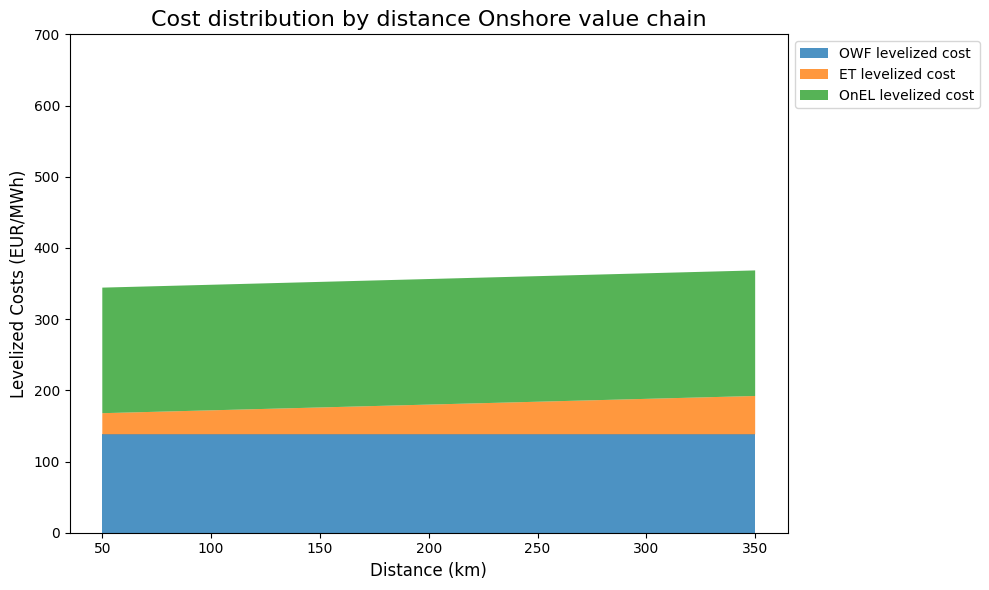

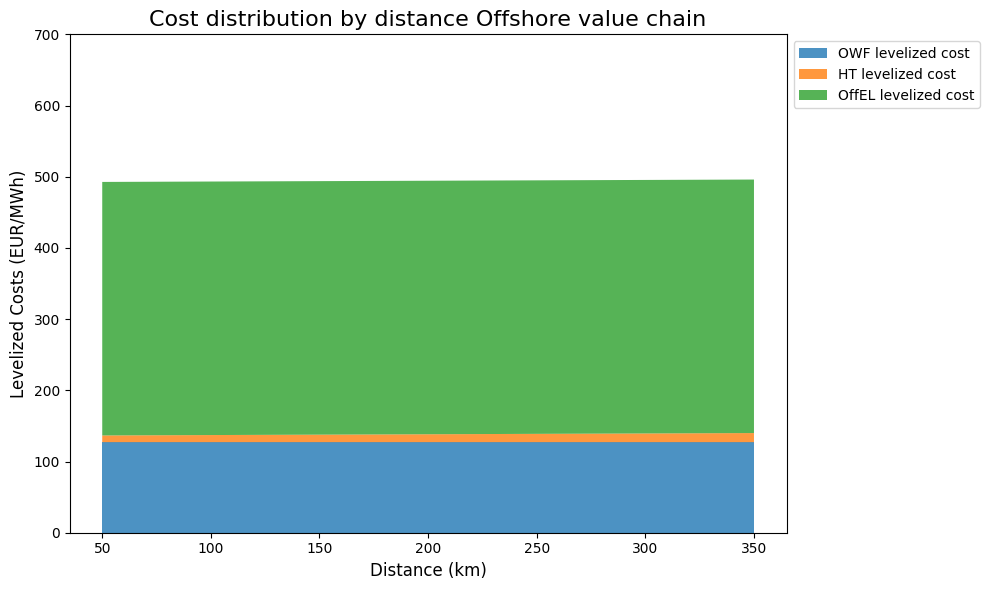

In [11]:
# Plotting the stackplot
def plot_stackplot(df, name):
    # Extract columns and index for plotting
    distances = df.columns.astype(int)  # x-axis (distances)
    cost_components = df.index          # rows as different cost components
    values = df.values                  # extract the actual data values
    
    # Create the stackplot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.stackplot(distances, values, labels=cost_components, alpha=0.8)

    # Customize the plot
    ax.set_title('Cost distribution by distance'+name, fontsize=16)
    ax.set_xlabel('Distance (km)', fontsize=12)
    ax.set_ylabel('Levelized Costs (EUR/MWh)', fontsize=12)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
    plt.xticks(distances)

    #optionally fix y-axis to get comparable plots (comment line below to remove fixed y-axis)
    ax.set_ylim(0, 700)  # Fix y-axis limit to 600

    plt.tight_layout()

    # Show the plot
    plt.show()

# Call the function to plot the stackplot
# Uncomment the lines to determine which stackplots to show. They depend in granualarity
#plot_stackplot(df_VC_costs_on_level1, ' Onshore value chain')
plot_stackplot(df_VC_costs_on_level3, ' Onshore value chain')
#plot_stackplot(df_VC_costs_on_level3, ' Onshore value chain')
#plot_stackplot(df_VC_costs_off_level1, ' Offshore value chain')
#plot_stackplot(df_VC_costs_off_level2, ' Offshore value chain')
plot_stackplot(df_VC_costs_off_level3, ' Offshore value chain')

Plot onshore vs offshore comparison by distance

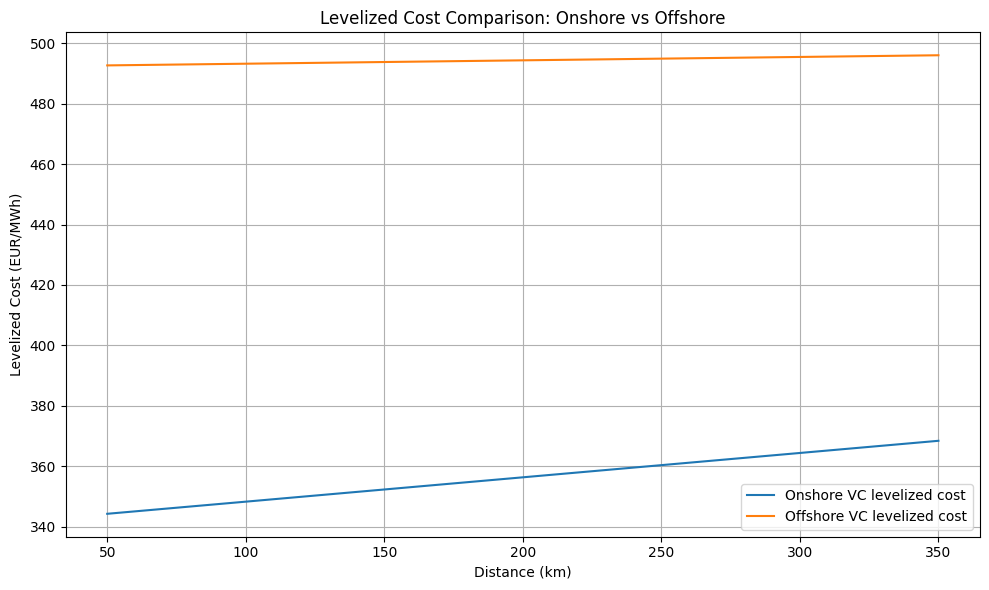

In [12]:
df_VC_costs_total = pd.concat([df_VC_costs_on_total, df_VC_costs_off_total])

#print(df_VC_costs_total)

def plot_lineplot(df):
    # Assuming your DataFrame is called 'df'
    # Transpose the DataFrame so distances become the x-axis and rows are the y-values
    df_transposed = df.T

    # Create the plot
    plt.figure(figsize=(10, 6))

    # Plot each row as a separate line
    for row in df.index:
        plt.plot(df.columns, df.loc[row], label=row)

    # Add labels and title
    plt.xlabel('Distance (km)')
    plt.ylabel('Levelized Cost (EUR/MWh)')
    plt.title('Levelized Cost Comparison: Onshore vs Offshore')
    plt.legend()

    # Show the plot
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_lineplot(df_VC_costs_total)

Offshore wind vs hybrid solar and wind value chain comparison

In [13]:
##### comment: this code can be made a bit more clean, but it was just a fast way to create the graphs. It is a bit less nice that previous variables are overwritten. Make sure to run the whole program twice: one time with solar capacity and one time without solar capacity in order to make the comparison.

#built big dataframe with all different cost components on different levels of specificality

ratio_OWF_OS = windfarm_capacity / (solar_capacity + windfarm_capacity)

df_VC_costs_off_level1 = pd.DataFrame()
df_VC_costs_off_level2 = pd.DataFrame()
df_VC_costs_off_level3 = pd.DataFrame()
OWF_tlc_off = pd.DataFrame(df_OWF_levelized_costs_off.sum()*ratio_OWF_OS +  df_OS_levelized_costs_off.sum()*(1-ratio_OWF_OS)).T
HT_tlc = pd.DataFrame(df_HT_costs_by_distance.sum()).T
OffEL_tlc = pd.DataFrame(df_OffEL_levelized_costs.sum()).T
OWF_tlc_off.index = ['OWF&OS levelized cost']
HT_tlc.index = ['HT levelized cost']
OffEL_tlc.index = ['OffEL levelized cost']

for distance in distances:
    df_VC_costs_off_level1_for_distance = pd.concat([df_OWF_levelized_costs_off.rename(columns={"cost": distance}), df_HT_costs_by_distance[distance], df_OffEL_levelized_costs.rename(columns={"cost": distance})])
    df_VC_costs_off_level2_for_distance = pd.concat([OWF_tlc_off.rename(columns={"cost": distance}), df_HT_costs_by_distance[distance], OffEL_tlc.rename(columns={"cost": distance})])
    df_VC_costs_off_level3_for_distance = pd.concat([OWF_tlc_off.rename(columns={"cost": distance}), HT_tlc[distance], OffEL_tlc.rename(columns={"cost": distance})])

    #print(df_VC_costs_on_level1_for_distance)
    if df_VC_costs_off_level1.empty:
        df_VC_costs_off_level1 = df_VC_costs_off_level1_for_distance
        df_VC_costs_off_level2 = df_VC_costs_off_level2_for_distance
        df_VC_costs_off_level3 = df_VC_costs_off_level3_for_distance
    else:    
        df_VC_costs_off_level1 = pd.concat([df_VC_costs_off_level1, df_VC_costs_off_level1_for_distance], axis=1)
        df_VC_costs_off_level2 = pd.concat([df_VC_costs_off_level2, df_VC_costs_off_level2_for_distance], axis=1)
        df_VC_costs_off_level3 = pd.concat([df_VC_costs_off_level3, df_VC_costs_off_level3_for_distance], axis=1)

df_VC_costs_off_total = pd.DataFrame(df_VC_costs_off_level3.sum()).T
df_VC_costs_off_total.index = ['Offshore VC levelized cost']

#uncomment to choose to visualise the table on a different granualarity (only 1 possible at once)
#df_VC_costs_off_level1.style.format(precision=2)
#df_VC_costs_off_level2.style.format(precision=2)
df_VC_costs_off_level3.style.format(precision=2)
#df_VC_costs_off_total.style.format(precision=2)




,50,100,150,200,250,300,350
OWF&OS levelized cost,137.90,137.90,137.90,137.90,137.90,137.90,137.90
HT levelized cost,9.45,10.01,10.57,11.12,11.68,12.24,12.80
OffEL levelized cost,356.07,356.07,356.07,356.07,356.07,356.07,356.07


In [15]:
#built multiple versions of combined value chain cost dataframe

#built big dataframe with all different cost components on different levels of specificality
df_VC_costs_on_level1 = pd.DataFrame()
df_VC_costs_on_level2 = pd.DataFrame()
df_VC_costs_on_level3 = pd.DataFrame()
OWF_tlc_on = pd.DataFrame(df_OWF_levelized_costs_on.sum()*ratio_OWF_OS +  df_OS_levelized_costs_on.sum()*(1-ratio_OWF_OS)).T
ET_tlc = pd.DataFrame(df_ET_costs_by_distance.sum()).T
OnEL_tlc = pd.DataFrame(df_OnEL_levelized_costs.sum()).T
OWF_tlc_on.index = ['OWF&OS levelized cost']
ET_tlc.index = ['ET levelized cost']
OnEL_tlc.index = ['OnEL levelized cost']

for distance in distances:
    df_VC_costs_on_level1_for_distance = pd.concat([df_OWF_levelized_costs_on.rename(columns={"cost": distance}), df_ET_costs_by_distance[distance], df_OnEL_levelized_costs.rename(columns={"cost": distance})])
    df_VC_costs_on_level2_for_distance = pd.concat([OWF_tlc_on.rename(columns={"cost": distance}), df_ET_costs_by_distance[distance], OnEL_tlc.rename(columns={"cost": distance})])
    df_VC_costs_on_level3_for_distance = pd.concat([OWF_tlc_on.rename(columns={"cost": distance}), ET_tlc[distance], OnEL_tlc.rename(columns={"cost": distance})])

    #print(df_VC_costs_on_level1_for_distance)
    if df_VC_costs_on_level1.empty:
        df_VC_costs_on_level1 = df_VC_costs_on_level1_for_distance
        df_VC_costs_on_level2 = df_VC_costs_on_level2_for_distance
        df_VC_costs_on_level3 = df_VC_costs_on_level3_for_distance
    else:    
        df_VC_costs_on_level1 = pd.concat([df_VC_costs_on_level1, df_VC_costs_on_level1_for_distance], axis=1)
        df_VC_costs_on_level2 = pd.concat([df_VC_costs_on_level2, df_VC_costs_on_level2_for_distance], axis=1)
        df_VC_costs_on_level3 = pd.concat([df_VC_costs_on_level3, df_VC_costs_on_level3_for_distance], axis=1)

df_VC_costs_on_total = pd.DataFrame(df_VC_costs_on_level3.sum()).T
df_VC_costs_on_total.index = ['Onshore VC levelized cost']

#uncomment to choose to visualise the table on a different granualarity (only 1 possible at once)
#df_VC_costs_on_level1.style.format(precision=2)
#df_VC_costs_on_level2.style.format(precision=2)
df_VC_costs_on_level3.style.format(precision=2)
#df_VC_costs_on_total.style.format(precision=2)

,50,100,150,200,250,300,350
OWF&OS levelized cost,149.89,149.89,149.89,149.89,149.89,149.89,149.89
ET levelized cost,29.66,33.67,37.70,41.73,45.76,49.79,53.82
OnEL levelized cost,176.36,176.36,176.36,176.36,176.36,176.36,176.36
